In [802]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [803]:
daily_data = pd.read_csv("../data/processed/daily_preference_returns_and_factors.csv")
daily_data

,date,CW,EW,EBC,CW-EW,CW-EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM
0,1970-12-30,0.002174,0.003301,0.003029,-0.001127,-0.000855,0.0018,0.0009,0.0008,0.0025,0.0015,0.0002,0.0005
1,1970-12-31,-0.001193,0.000573,0.000399,-0.001766,-0.001592,-0.0010,0.0027,-0.0011,0.0011,0.0003,0.0002,0.0008
2,1971-01-04,-0.010787,-0.007395,-0.006505,-0.003392,-0.004283,-0.0099,0.0059,0.0066,-0.0056,0.0042,0.0002,-0.0002
3,1971-01-05,0.007279,0.011010,0.009020,-0.003730,-0.001741,0.0082,0.0071,0.0003,-0.0035,-0.0038,0.0002,-0.0142
4,1971-01-06,0.006495,0.012524,0.010720,-0.006029,-0.004225,0.0074,0.0091,0.0050,-0.0060,0.0001,0.0002,-0.0093
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13614,2024-12-24,0.011481,0.007806,0.007682,0.003675,0.003798,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.0002,0.0067
13615,2024-12-26,-0.000346,0.001047,0.001133,-0.001393,-0.001479,0.0001,0.0107,-0.0018,-0.0042,0.0036,0.0002,0.0000
13616,2024-12-27,-0.011024,-0.007075,-0.006283,-0.003949,-0.004741,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.0002,-0.0085
13617,2024-12-30,-0.010723,-0.009846,-0.009267,-0.000877,-0.001456,-0.0109,0.0025,0.0074,0.0055,0.0014,0.0002,0.0009


In [804]:
daily_data = daily_data.set_index("date")
daily_data

,CW,EW,EBC,CW-EW,CW-EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM
date,,,,,,,,,,,,
1970-12-30,0.002174,0.003301,0.003029,-0.001127,-0.000855,0.0018,0.0009,0.0008,0.0025,0.0015,0.0002,0.0005
1970-12-31,-0.001193,0.000573,0.000399,-0.001766,-0.001592,-0.0010,0.0027,-0.0011,0.0011,0.0003,0.0002,0.0008
1971-01-04,-0.010787,-0.007395,-0.006505,-0.003392,-0.004283,-0.0099,0.0059,0.0066,-0.0056,0.0042,0.0002,-0.0002
1971-01-05,0.007279,0.011010,0.009020,-0.003730,-0.001741,0.0082,0.0071,0.0003,-0.0035,-0.0038,0.0002,-0.0142
1971-01-06,0.006495,0.012524,0.010720,-0.006029,-0.004225,0.0074,0.0091,0.0050,-0.0060,0.0001,0.0002,-0.0093
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011481,0.007806,0.007682,0.003675,0.003798,0.0111,-0.0012,-0.0006,-0.0011,-0.0036,0.0002,0.0067
2024-12-26,-0.000346,0.001047,0.001133,-0.001393,-0.001479,0.0001,0.0107,-0.0018,-0.0042,0.0036,0.0002,0.0000
2024-12-27,-0.011024,-0.007075,-0.006283,-0.003949,-0.004741,-0.0117,-0.0044,0.0057,0.0039,0.0004,0.0002,-0.0085


In [805]:
daily_ports = pd.read_csv("../data/processed/daily_quantile_returns_3x3.csv")
daily_ports

,date,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
0,1970-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1970-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1970-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1970-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
13866,2024-12-24,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640
13867,2024-12-26,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003
13868,2024-12-27,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013
13869,2024-12-30,-0.020547,-0.008966,-0.008236,-0.012880,-0.009100,-0.007649,-0.009887,-0.009197,-0.008851


In [806]:
daily_ports = daily_ports.set_index("date")
daily_ports

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
date,,,,,,,,,
1970-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.027693,0.013346,0.008664,0.015098,0.009332,0.006488,0.010010,0.005395,0.002640
2024-12-26,-0.000674,0.002388,0.003756,0.000400,0.001184,0.001303,-0.001831,0.001282,0.001003
2024-12-27,-0.019317,-0.008767,-0.007529,-0.011680,-0.005518,-0.005560,-0.013549,-0.003499,-0.002013


In [807]:
cw = daily_data["CW"]
q1q3 = daily_ports["EBC_High_Pref_Low"]

## MVO

In [808]:
# Setup Window
rebalance_freq = 21*3 # days
lookback = 252*3 # days

In [809]:
df = pd.concat([cw.rename("CW"), q1q3.rename("Q1Q3")], axis=1).dropna()


In [810]:
def gmv_w(Sigma, ridge = 1e-8):
    n = Sigma.shape[0]
    Sigma = 0.5*(Sigma + Sigma.T) + ridge*np.eye(n)

    def obj(w):
        return w @ Sigma @ w

    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0,1)] * n

    w0 = np.ones(n)/n
    res = minimize(obj, w0, method='SLSQP',
                   bounds=bounds,
                   constraints=cons)

    if not res.success:
        raise ValueError(res.message)

    return res.x

In [811]:
wts = pd.DataFrame(index=df.index, columns=["CW", "Q1Q3"], dtype=float)
ret = pd.Series(index=df.index, dtype=float, name=f"GMV_rf{rebalance_freq}_lb{lookback}")

In [812]:
dates = df.index.to_list()

In [813]:
# True: full history / False: fixed lookback
use_full_history = True

# quarterly
min_obs = 21*12

# for full period
t = min_obs if use_full_history else lookback
# for fixed days of lookback
# t = lookback

while t < len(df):
    # if want all period lookback
    if use_full_history:
        train = df.iloc[:t]
    # If want fixed days of lookback
    else:
        train = df.iloc[t - lookback: t]

    Sigma = train.cov().values
    if not np.isfinite(Sigma).all():
        t += 1
        continue

    w = gmv_w(Sigma)

    t_end = min(t + rebalance_freq, len(df))
    block = df.iloc[t:t_end]

    wts.iloc[t:t_end] = w
    ret.iloc[t:t_end] = (block.values @ w)

    t = t_end

ret = ret.dropna()
wts = wts.loc[ret.index]

ret.tail(), wts.tail()

(date
 2024-12-24    0.010072
 2024-12-26    0.001705
 2024-12-27   -0.009277
 2024-12-30   -0.009479
 2024-12-31   -0.000966
 Name: GMV_rf63_lb756, dtype: float64,
              CW  Q1Q3
 date                 
 2024-12-24  0.5   0.5
 2024-12-26  0.5   0.5
 2024-12-27  0.5   0.5
 2024-12-30  0.5   0.5
 2024-12-31  0.5   0.5)

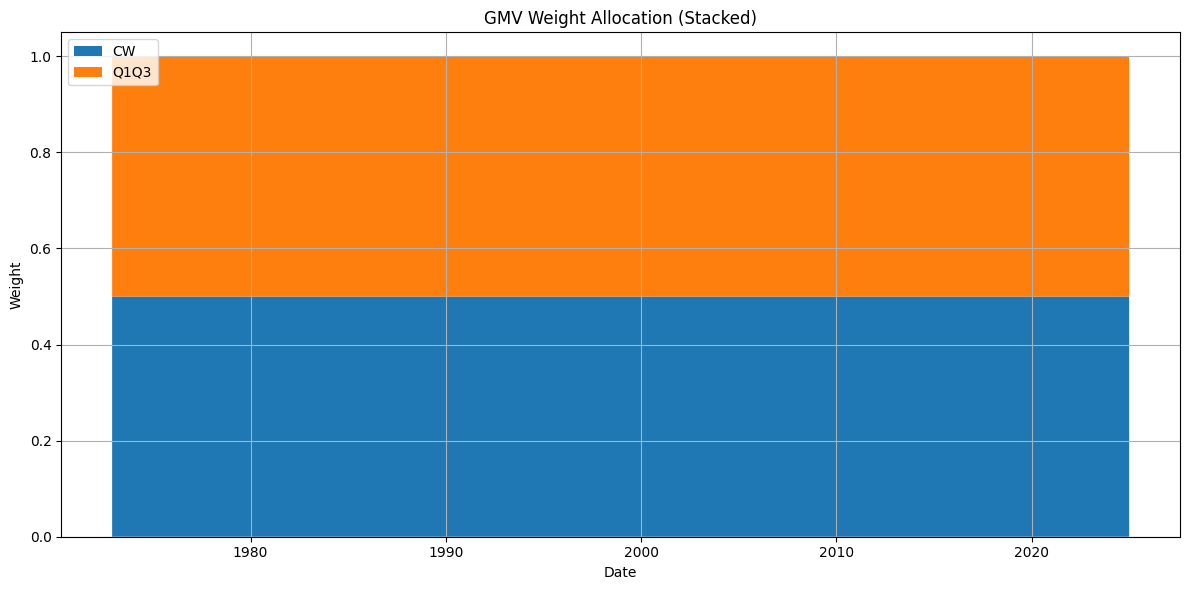

In [814]:
plt.figure(figsize=(12,6))

wts.index = pd.to_datetime(wts.index)
plt.stackplot(
    wts.index,
    wts["CW"],
    wts["Q1Q3"],
    labels=["CW", "Q1Q3"]
)

plt.title("GMV Weight Allocation (Stacked)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [815]:
print("first valid:", wts.dropna(how="all").index.min())
print("last  valid:", wts.dropna(how="all").index.max())

first valid: 1972-11-29 00:00:00
last  valid: 2024-12-31 00:00:00


In [816]:
import matplotlib.pyplot as plt

plot_df = pd.concat([df.loc[ret.index, "CW"], df.loc[ret.index, "Q1Q3"], ret], axis=1)
plot_df = plot_df.copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()
plot_df.columns = ["CW", "Q1Q3", ret.name if ret.name is not None else "MVO"]

#plot_df["CW-MVO"] = plot_df["CW"] - plot_df[plot_df.columns[2]]

logw = np.log1p(plot_df).cumsum()

plot_df

,CW,Q1Q3,GMV_rf63_lb756
date,,,
1972-11-29,0.000556,0.003619,0.002087
1972-11-30,0.001661,0.007942,0.004802
1972-12-01,0.006324,0.006031,0.006177
1972-12-04,0.003558,-0.000788,0.001385
1972-12-05,-0.001497,-0.006217,-0.003857
...,...,...,...
2024-12-24,0.011481,0.008664,0.010072
2024-12-26,-0.000346,0.003756,0.001705
2024-12-27,-0.011024,-0.007529,-0.009277


/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_88369/2447330334.py:17: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=8)


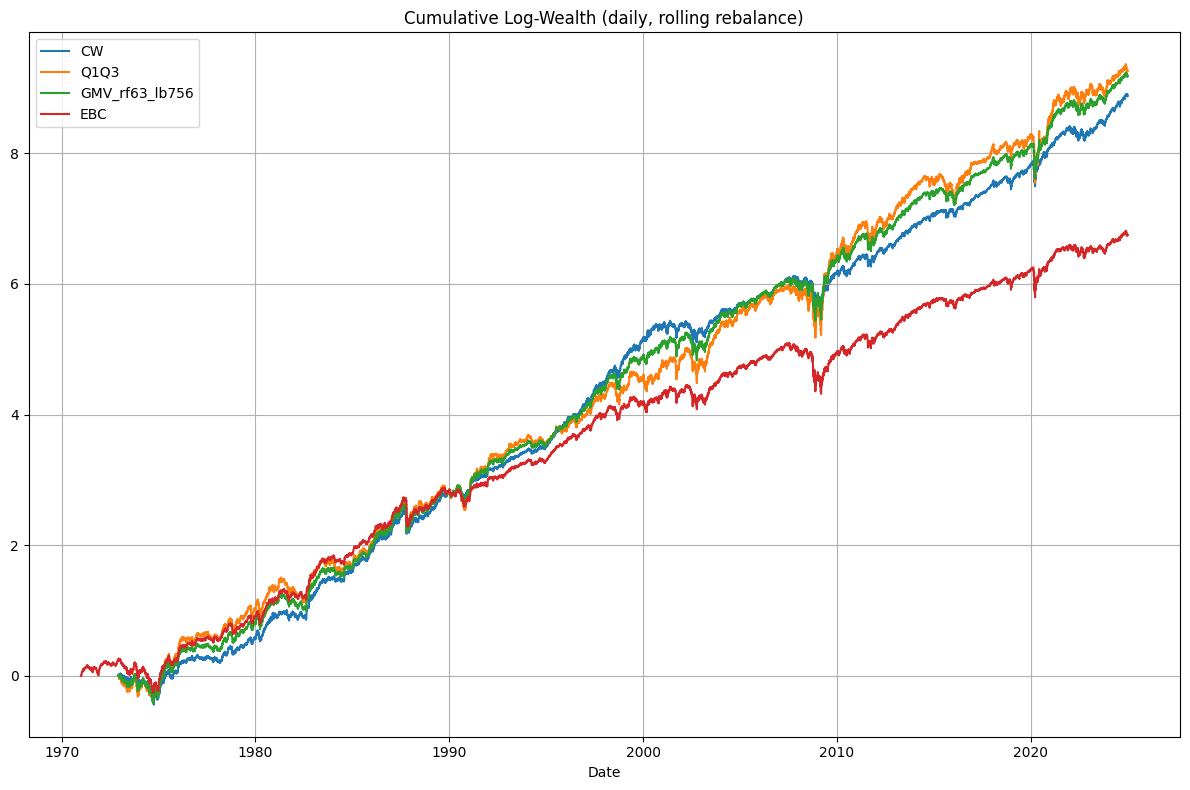

In [817]:
plt.figure(figsize=(12,8))
for c in logw.columns:
    plt.plot(logw.index, logw[c], label=c)

daily_data.index = pd.to_datetime(daily_data.index)
logpref = np.log1p(daily_data["CW-EBC"]).cumsum()
#plt.plot(daily_data.index, logpref, label="CW-EBC")

log_ebc = np.log1p(daily_data["EBC"]).cumsum()
plt.plot(daily_data.index, log_ebc, label="EBC")


plt.title("Cumulative Log-Wealth (daily, rolling rebalance)")
plt.xlabel("Date")
plt.legend()
plt.grid()
plt.locator_params(axis='x', nbins=8)
plt.tight_layout()
plt.show()


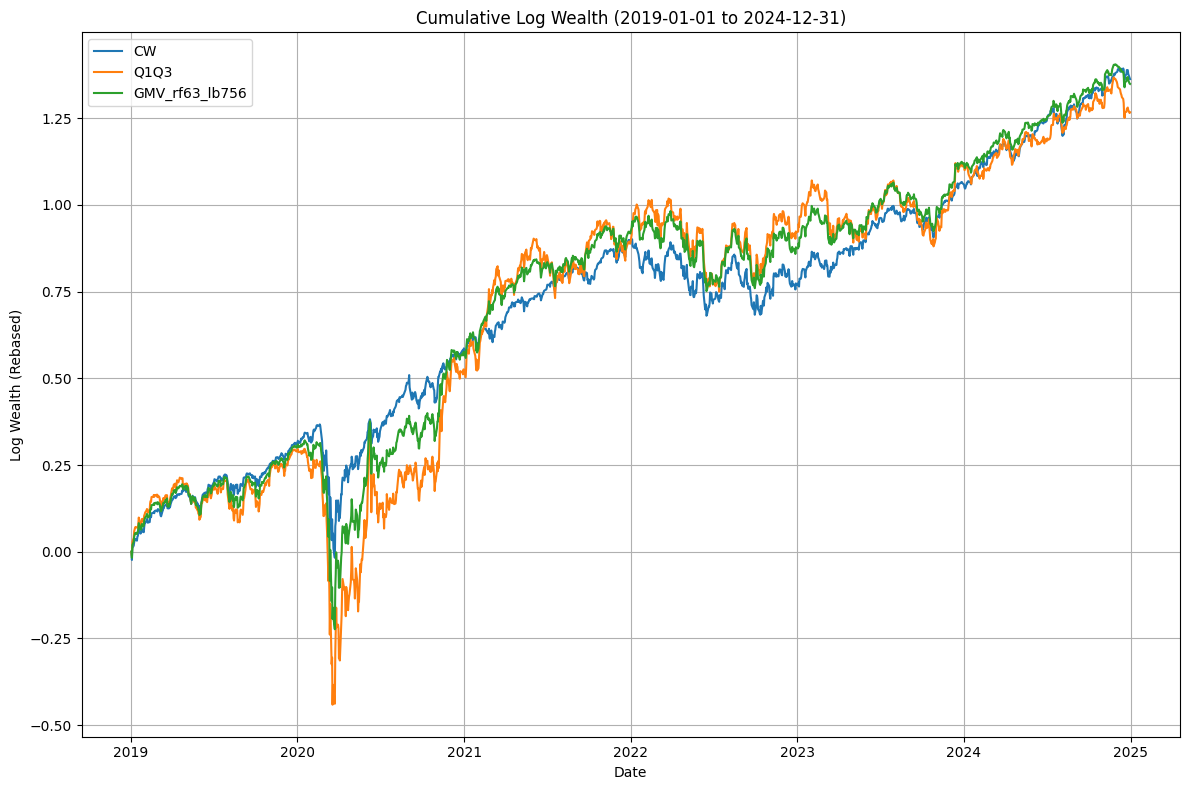

In [818]:
start = "2019-01-01"
end   = "2024-12-31"

sub_logw = logw.loc[start:end].copy()


sub_logw = sub_logw - sub_logw.iloc[0]

plt.figure(figsize=(12,8))
for c in sub_logw.columns:
    plt.plot(sub_logw.index, sub_logw[c], label=c)

plt.title(f"Cumulative Log Wealth ({start} to {end})")
plt.xlabel("Date")
plt.ylabel("Log Wealth (Rebased)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_88369/574235997.py:22: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=8)


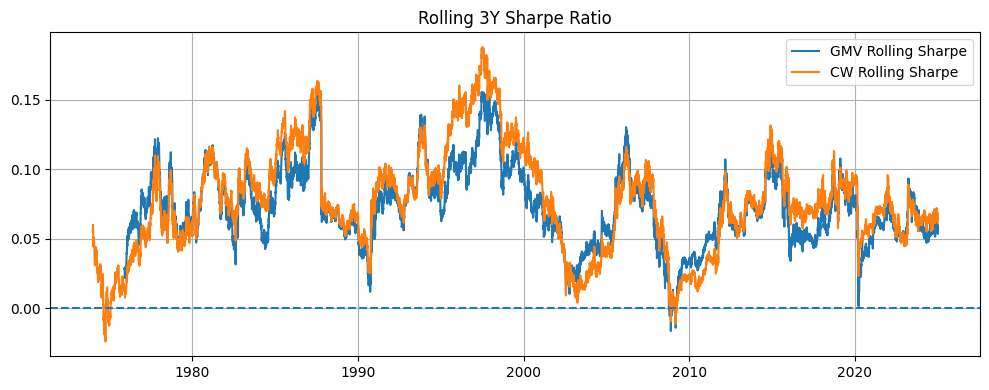

In [819]:
window = 252*3

rolling_sharpe = (
    ret.rolling(window).mean() /
    ret.rolling(window).std()
)
rolling_cw_sharpe = (
        cw.rolling(window).mean() /
        cw.rolling(window).std()
)

rolling_sharpe.index = pd.to_datetime(rolling_sharpe.index)
rolling_cw_sharpe.index = pd.to_datetime(rolling_cw_sharpe.index)
plt.figure(figsize=(10,4))
plt.plot(rolling_sharpe, label="GMV Rolling Sharpe")
plt.plot(rolling_cw_sharpe, label="CW Rolling Sharpe")

plt.axhline(0, linestyle="--")
plt.title("Rolling 3Y Sharpe Ratio")
plt.grid()
plt.legend()
plt.locator_params(axis='x', nbins=8)
plt.tight_layout()
plt.show()


/var/folders/0x/m7zdg5ws40d82m_y7djyss7r0000gn/T/ipykernel_88369/2332348417.py:13: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=8)


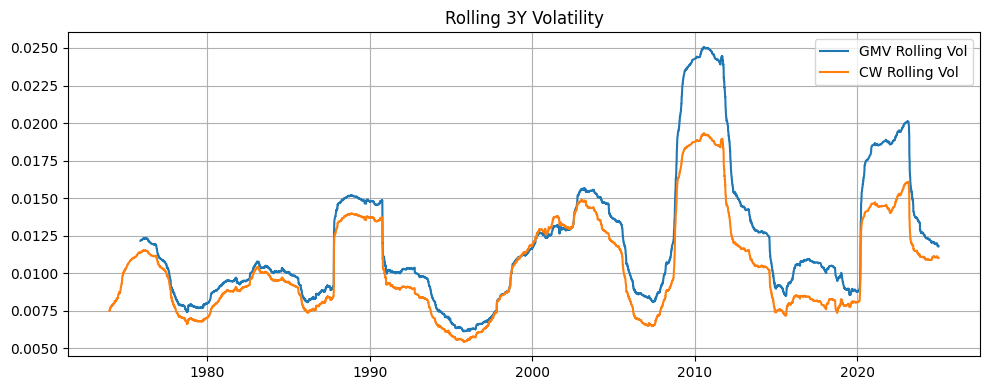

In [820]:
rolling_vol = ret.rolling(252*3).std()
rolling_vol.index = pd.to_datetime(rolling_vol.index)

rolling_cw_vol = cw.rolling(252*3).std()
rolling_cw_vol.index = pd.to_datetime(rolling_cw_vol.index)

plt.figure(figsize=(10,4))
plt.plot(rolling_vol, label="GMV Rolling Vol")
plt.plot(rolling_cw_vol, label="CW Rolling Vol")

plt.title("Rolling 3Y Volatility")
plt.legend()
plt.locator_params(axis='x', nbins=8)
plt.tight_layout()
plt.grid()
plt.show()

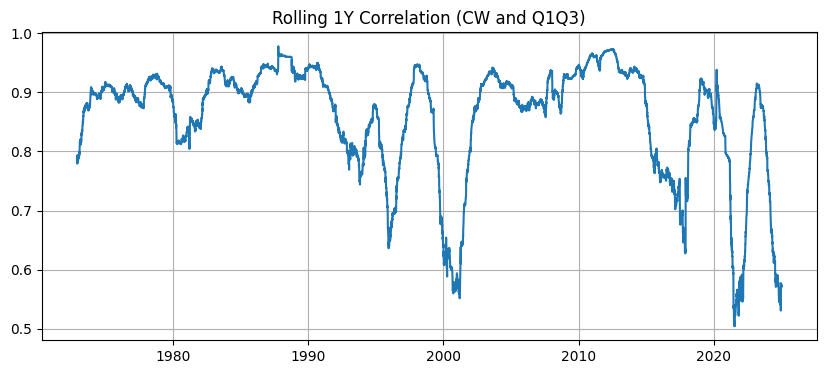

In [821]:
rolling_corr = (
    df["CW"].rolling(252).corr(df["Q1Q3"])
)
rolling_corr.index = pd.to_datetime(rolling_corr.index)
plt.figure(figsize=(10,4))
plt.plot(rolling_corr)
plt.title("Rolling 1Y Correlation (CW and Q1Q3)")
plt.grid()
plt.show()

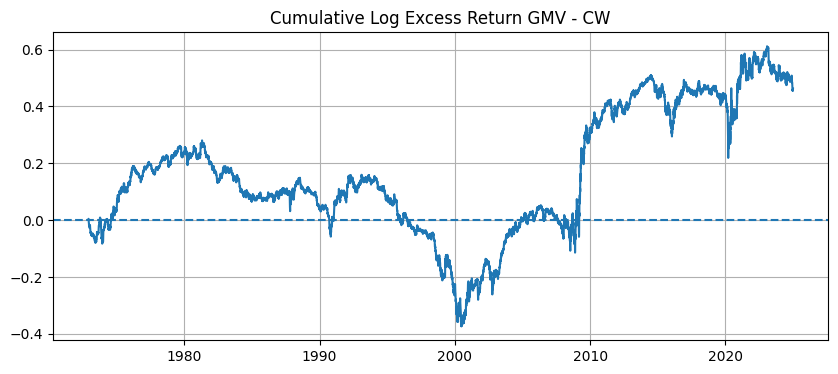

In [822]:
excess = ret - df["CW"].loc[ret.index]

cum_excess = np.log1p(excess).cumsum()
cum_excess.index = pd.to_datetime(excess.index)

plt.figure(figsize=(10,4))
plt.plot(cum_excess)
plt.title("Cumulative Log Excess Return GMV - CW")
plt.axhline(0, linestyle="--")
plt.grid()
plt.show()